# **Project Name**    - Yes Bank Stock Price Prediction



##### **Project Type**    - Regression
##### **Contribution**    - Individual/ Aankit Sharma


# **Project Summary **

# About Yes Bank

**Yes Bank** Limited is one of India's leading private sector banks. It was founded by Rana Kapoor and Ashok Kapur and was officially established on November 21, 2003. The bank commenced its operations in 2004, providing a wide range of banking and financial services to corporate, retail, and institutional customers. Over the years, Yes Bank experienced rapid growth and became one of the fastest-growing private banks in India.

**This project focuses on predicting the future closing price of Yes Bank shares using historical stock market data and machine learning techniques. The dataset contains daily stock prices from July 2005 to November 2020, including features such as Open, High, Low, and Close prices. The objective is to analyze historical price movements, identify patterns, and build a predictive model that can estimate future share prices.**


**The dataset used in this project contains historical stock prices of Yes Bank from July 2005 to November 2020**. During this period, the bank's stock exhibited significant growth as well as a major decline. **The share price increased from approximately ₹13 in July 2005 to around ₹400 in August 2018, reflecting the bank's strong market performance and investor confidence during its growth phase.**

However, after August 2018, the stock price witnessed a steep fall. The decline was primarily caused by aggressive and risky lending practices, under-reporting of bad loans, increasing Non-Performing Assets (NPAs), and regulatory interventions by the Reserve Bank of India (RBI). These events led to a severe loss of investor confidence and a sharp drop in the bank's market value.



# **GitHub Link -**

https://github.com/aankitsharma/Yes-Bank-Price---Supervised-ML-Model-

# **Problem Statement**


**Stock market price prediction is a challenging task due to the dynamic nature of financial markets and the influence of multiple economic and company-specific factors. Accurate prediction of stock prices can help investors, analysts, and financial institutions make informed investment decisions and manage risks effectively.

This project aims to develop a machine learning model to predict the closing price of Yes Bank shares using historical stock market data from July 2005 to November 2020. The dataset covers a period of substantial growth, where the stock price increased from around ₹13 to nearly ₹400, as well as a significant decline following the financial and regulatory crisis faced by the bank after 2018.

One of the major challenges in this project is handling the sharp fall in Yes Bank's share price. Unlike statistical anomalies or data entry errors, this decline was caused by actual business events, including aggressive lending practices, rising non-performing assets (NPAs), and regulatory actions. Therefore, these observations should not be treated as outliers but as important market events that the predictive model must learn from.

The objective is to analyze historical trends, build a robust prediction model, and evaluate its performance in forecasting future Yes Bank stock prices while preserving the real-world characteristics and volatility present in the data.**

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('data_YesBank_StockPrices.csv')

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(185, 5)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


<Axes: >

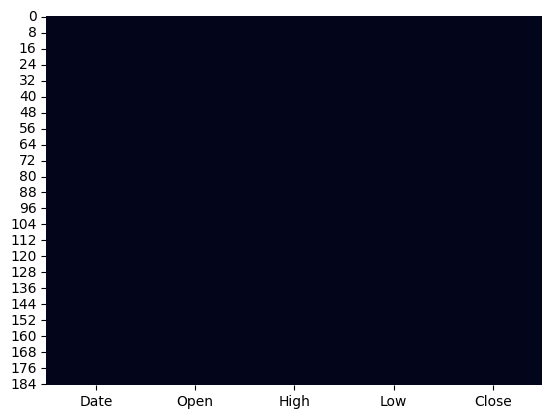

In [ ]:
# Visualizing the missing values
sns.heatmap(df.isnull(), cbar=False)

### What did you know about your dataset?

Dataset contain 5 columns and 185 rows which have date,open,low,high,close of share. Each rows contain monthly share price.

In this data set there is not null values,duplicates value and no missing values.



## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

**Date - Contain month and year

Open - Monthly opening price of share

Close - Monthly closing price of share

Low - Monthly low price of share

High - Monthly high price of share**

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
Date,185
Open,183
High,184
Low,183
Close,185


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Write your code to make your dataset analysis ready.
#Extract month and year from date
df['Date'] = pd.to_datetime(df['Date'], format='%b-%y')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df

,Date,Open,High,Low,Close,Month,Year
0,2005-07-01,13.00,14.00,11.25,12.46,7,2005
1,2005-08-01,12.58,14.88,12.55,13.42,8,2005
2,2005-09-01,13.48,14.87,12.27,13.30,9,2005
3,2005-10-01,13.20,14.47,12.40,12.99,10,2005
4,2005-11-01,13.35,13.88,12.88,13.41,11,2005
...,...,...,...,...,...,...,...
180,2020-07-01,25.60,28.30,11.10,11.95,7,2020
181,2020-08-01,12.00,17.16,11.85,14.37,8,2020
182,2020-09-01,14.30,15.34,12.75,13.15,9,2020
183,2020-10-01,13.30,14.01,12.11,12.42,10,2020


### What all manipulations have you done and insights you found?

As ealier we found that there are not null values,duplicates value and no outliers because data is genuine due to fall in stock price which is natural and we can consider them as outliers.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Price Distribution

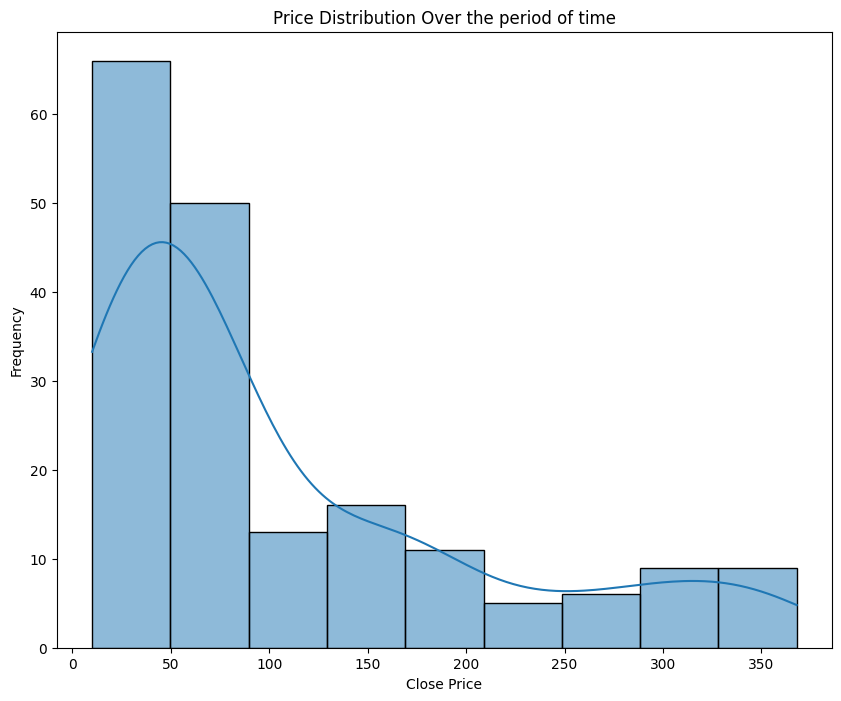

In [ ]:
# Chart - 1 visualization code
plt.figure(figsize=(10,8))
sns.histplot(df.Close,kde=True)
plt.title('Price Distribution Over the period of time')
plt.xlabel('Close Price')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Provide the distribution of the price.

##### 2. What is/are the insight(s) found from the chart?

Most of the time share  closing price range between 15 to 50 and after that price range is 50 to 100. sometime share closing range is 300 to 350 which is rise.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Data is right skewed and not normally distributed.

#### Chart - 2 Closing price Over the time

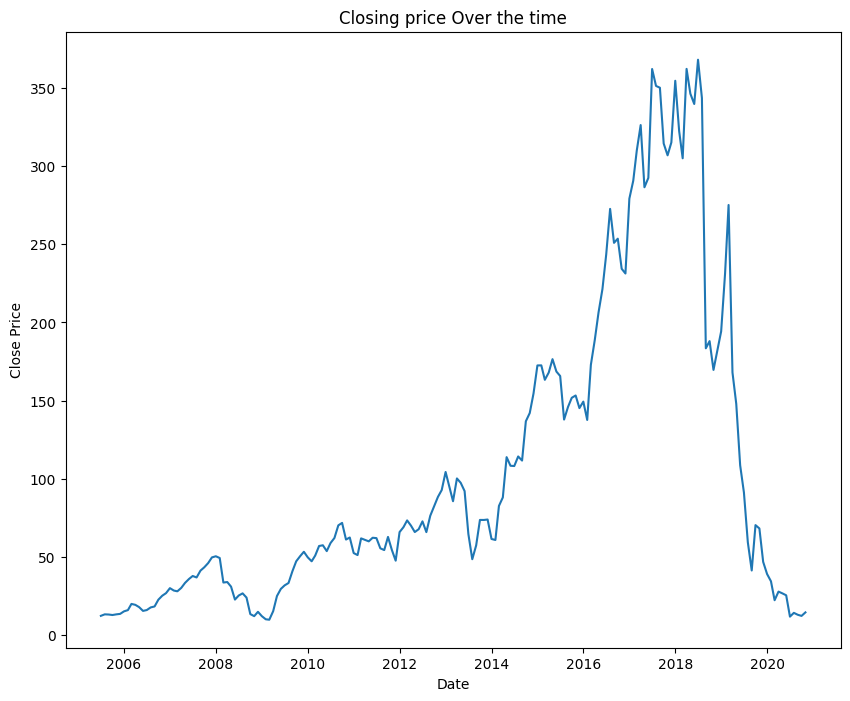

In [ ]:
# Chart - 2 visualization code
plt.figure(figsize=(10,8))
sns.lineplot(x='Date',y='Close',data=df)
plt.title('Closing price Over the time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

##### 1. Why did you pick the specific chart?

Line chart provide the insight about  closing price range over the period of time.

##### 2. What is/are the insight(s) found from the chart?

Ealier 2006 price is around 20 and over the time share price rise. In 2018 share price is highest and have a sharp fall from 350 to 180. after that share going down and reach it lowest again in 2020.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Insights from the stock price distribution help understand historical trends and volatility, enabling the development of more accurate forecasting models. This can support better investment decisions, risk management, and strategic financial planning.

#### Chart - 3 Relationship Between Closing and Opening price

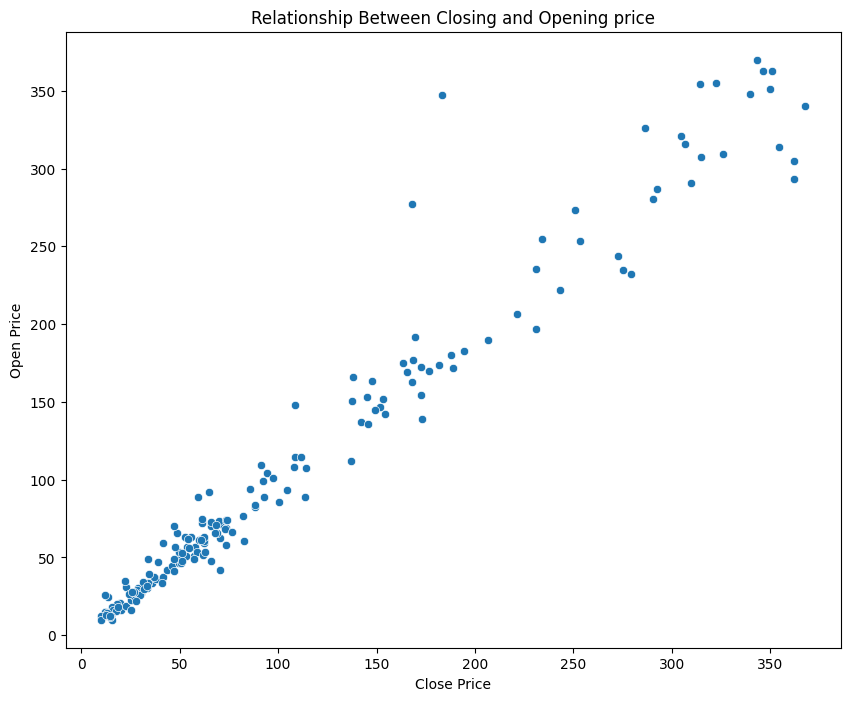

In [ ]:
# Chart - 3 visualization code
plt.figure(figsize=(10,8))
sns.scatterplot(x=df.Close,y=df.Open)
plt.title('Relationship Between Closing and Opening price')
plt.xlabel('Close Price')
plt.ylabel('Open Price')
plt.show()

##### 1. Why did you pick the specific chart?

Show the relationship between closing and opening price of share.

##### 2. What is/are the insight(s) found from the chart?

The scatter plot shows a strong positive linear relationship between the opening and closing prices of Yes Bank stock, with most data points closely following an upward trend.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong positive relationship between opening and closing prices indicates that opening price is a key predictor of closing price, improving the accuracy of forecasting models.

#### Chart - 4 Relationship  Between Closing and high


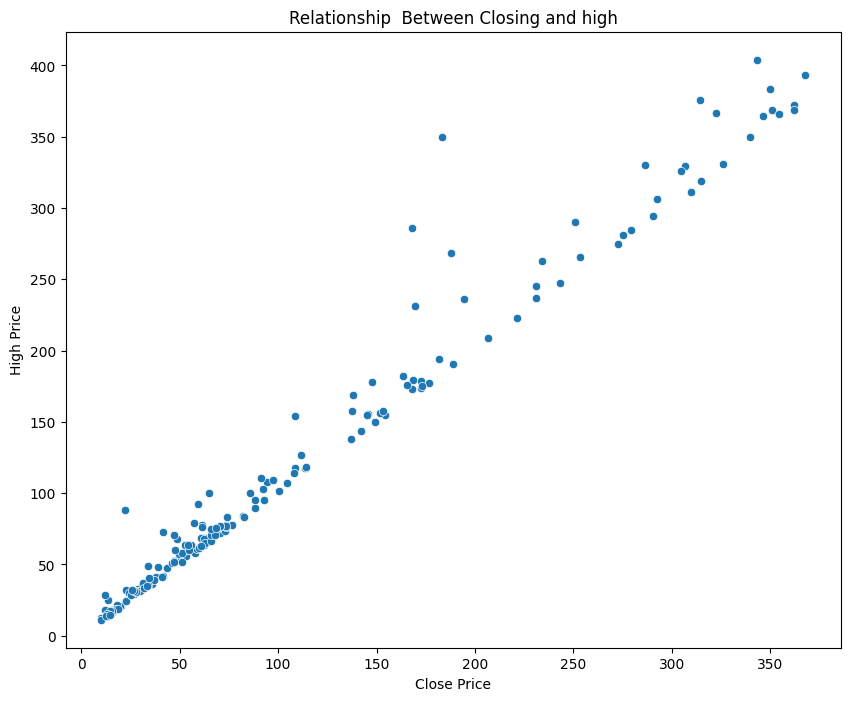

In [ ]:
# Chart - 4 visualization code
plt.figure(figsize=(10,8))
sns.scatterplot(x=df.Close,y=df.High)
plt.title('Relationship  Between Closing and high')
plt.xlabel('Close Price')
plt.ylabel('High Price')
plt.show()

##### 1. Why did you pick the specific chart?

Provide the relationship between the closing and high price.

##### 2. What is/are the insight(s) found from the chart?

There is a linear relationship between closing and high price


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The strong positive relationship between the closing and high prices indicates that the day's high price is a valuable predictor for forecasting stock movements.

#### Chart - 5 Relationship Between Closing and Low

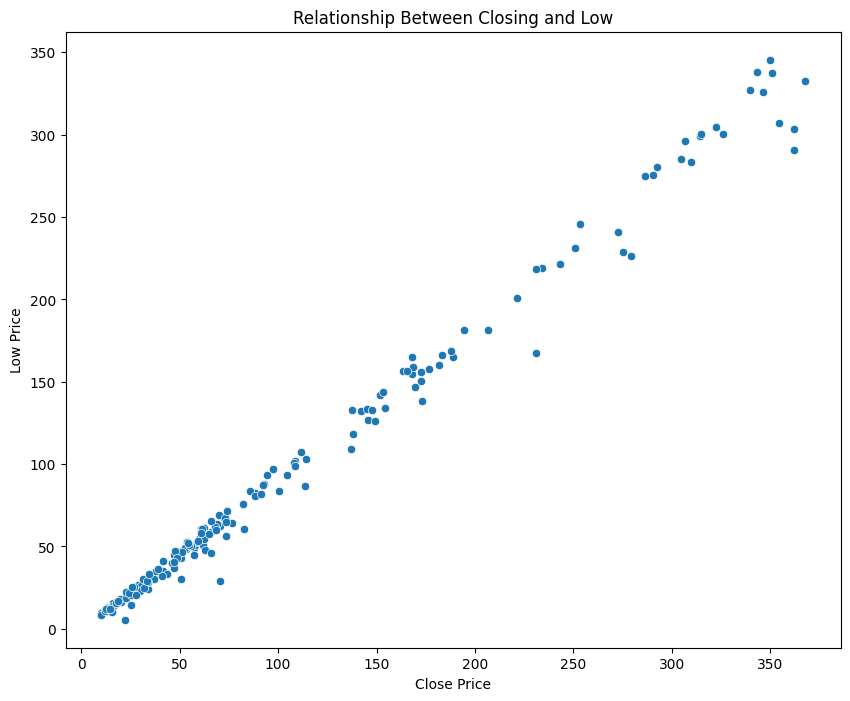

In [ ]:
# Chart - 5 visualization code
plt.figure(figsize=(10,8))
sns.scatterplot(x=df.Close,y=df.Low)
plt.title('Relationship Between Closing and Low')
plt.xlabel('Close Price')
plt.ylabel('Low Price')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to visualize the relationship and correlation between two continuous variables, helping identify patterns and trends.

##### 2. What is/are the insight(s) found from the chart?

There is a linear relationship between closing and low of share price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

This relationship help the forecasting the share price.

#### Chart - 6 - Correlation Heatmap

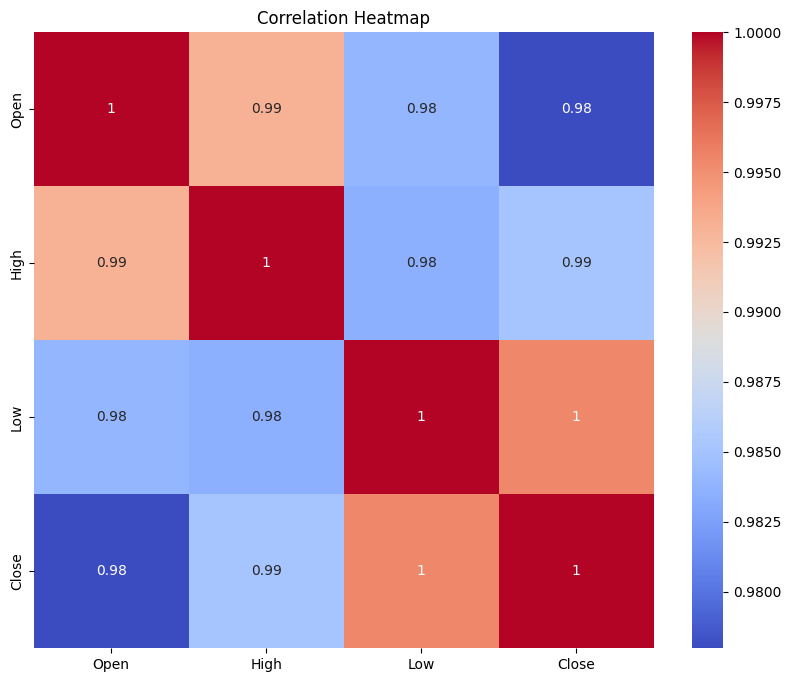

In [ ]:
# Correlation Heatmap visualization code
df_cor = df.drop(['Date','Month','Year'],axis=1)
corr_matrix = df_cor.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

##### 1. Why did you pick the specific chart?

Provide the correlation between the price.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows a very strong positive correlation (0.98–1.00) among the Open, High, Low, and Close prices, indicating that they move closely together.
This suggests that these features are highly influential and can be effectively used for stock price prediction models.

#### Chart - 7 - Pair Plot

<Figure size 1000x800 with 0 Axes>

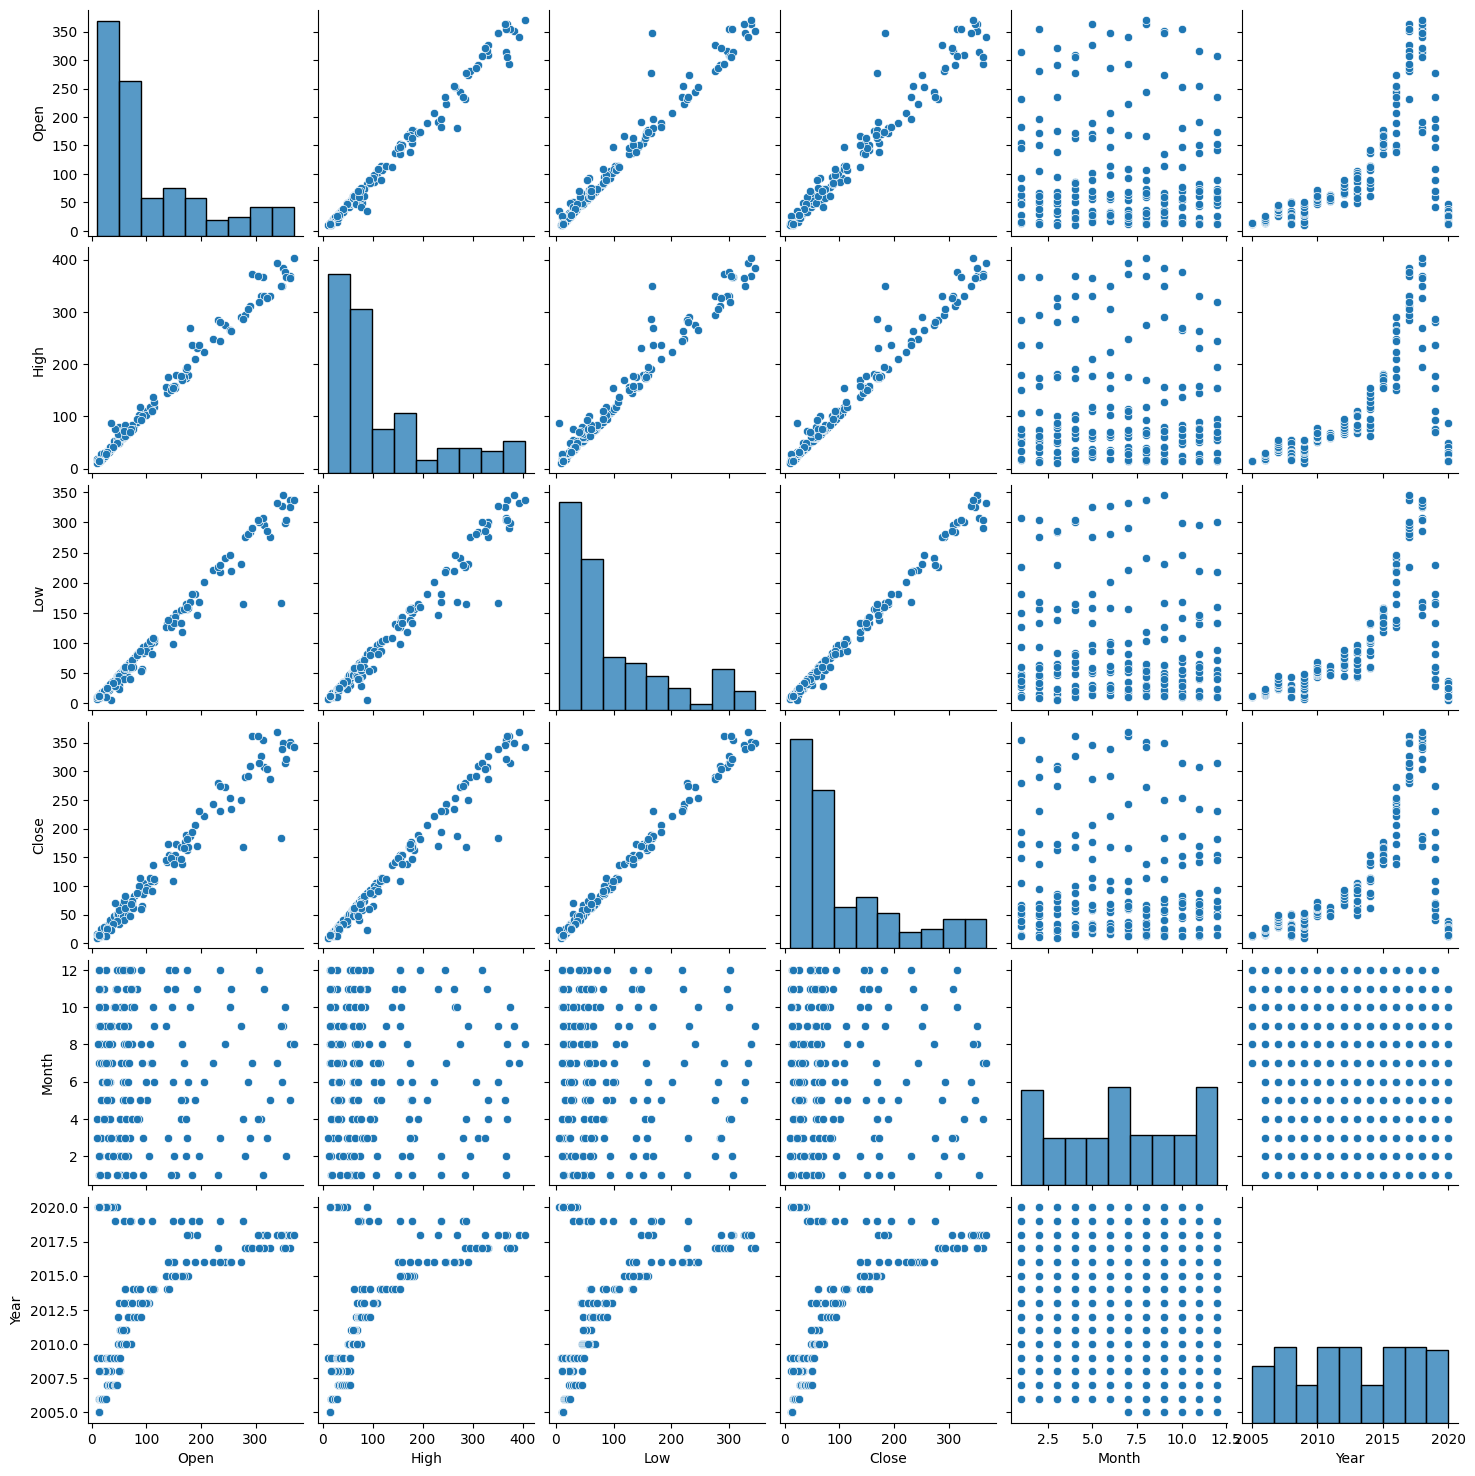

In [ ]:
# Pair Plot visualization code
plt.figure(figsize=(10,8))
sns.pairplot(df)
plt.show()

##### 1. Why did you pick the specific chart?

It Shows the overall picture of the data.

##### 2. What is/are the insight(s) found from the chart?

Open, High, Low, Close are highly correlated — near-perfect linear relationships among all four price columns, as expected in stock/commodity data.

Right-skewed price distribution — histograms for Open, High, Low, Close show most values clustered at lower prices (0–100 range), with few extreme high values.

Month has no pattern with prices — scatter plots between Month and price columns show random, uniform spread → no seasonal price trend.

Year vs Price shows gradual increase — prices appear to rise over time (2005→2020), suggesting a long-term upward trend.

Year distribution is fairly uniform — data is spread across ~15 years with roughly equal representation per year.

Month distribution is slightly uneven — some months have slightly more data points than others.



## ***5. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation
df.isnull().sum() # There is no missing value in the dataset

,0
Date,0
Open,0
High,0
Low,0
Close,0
Month,0
Year,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

There is no missing value.

### 2. Handling Outliers

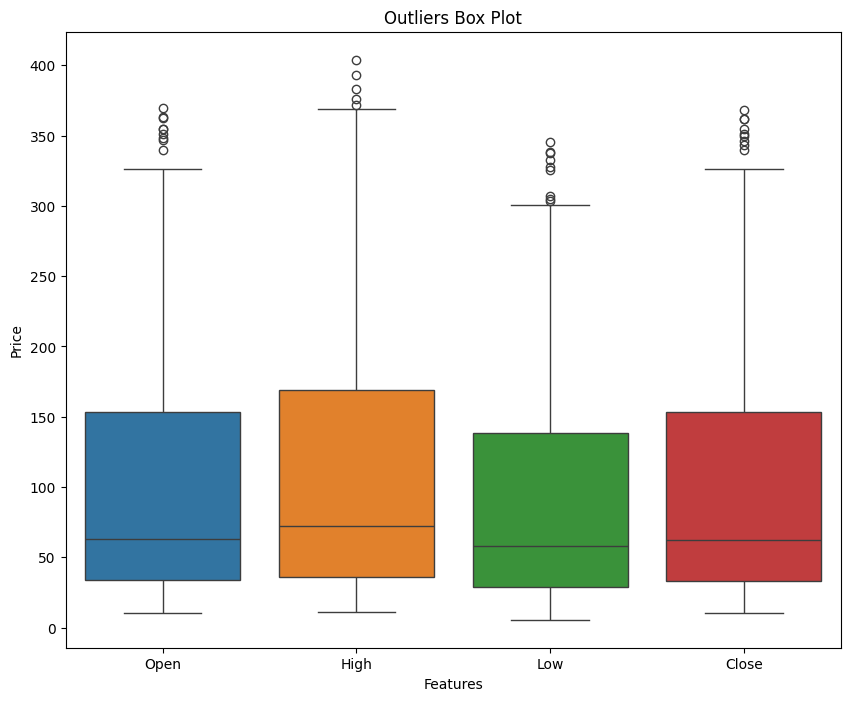

In [ ]:
# Handling Outliers & Outlier treatments
#let check the outliers
df_box = df.drop(['Date','Month','Year'],axis=1)
plt.figure(figsize=(10,8))
sns.boxplot(df_box)
plt.title('Outliers Box Plot')
plt.xlabel('Features')
plt.ylabel('Price')
plt.show()

##### What all outlier treatment techniques have you used and why did you use those techniques?

I am not doing any outliers treatment because these are natural value.In one month price fall from 380 to 180. This seem as outliers but they are not.Fall in price is natural cause it happened due to  aggressive and risky lending practices, under-reporting of bad loans, increasing Non-Performing Assets (NPAs), and regulatory interventions by the Reserve Bank of India (RBI). These events led to a severe loss of investor confidence and a sharp drop in the bank's market value.

### 3. Categorical Encoding - No categorical columns.

In [ ]:
# Encode your categorical columns
df.head()
# there is not categorical columns.

,Date,Open,High,Low,Close,Month,Year
0,2005-07-01,13.00,14.00,11.25,12.46,7,2005
1,2005-08-01,12.58,14.88,12.55,13.42,8,2005
2,2005-09-01,13.48,14.87,12.27,13.30,9,2005
3,2005-10-01,13.20,14.47,12.40,12.99,10,2005
4,2005-11-01,13.35,13.88,12.88,13.41,11,2005


#### What all categorical encoding techniques have you used & why did you use those techniques?

Due to no categorical column no need of encoding.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features
# I have already extract month and year from date column in data wrangling so there no need of it.
"""Feature correlation was analyzed using a heatmap.
Although some features showed a high degree of correlation,
they were retained because they contain important information for stock price prediction and
 do not adversely affect the selected machine learning models."""

'Feature correlation was analyzed using a heatmap.\nAlthough some features showed a high degree of correlation,\nthey were retained because they contain important information for stock price prediction and\n do not adversely affect the selected machine learning models.'

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting
X = df.drop(['Date','Close',],axis=1)
y = df['Close']

##### What all feature selection methods have you used  and why?

I extract month and year from date because every quater financial result are announced and they impact the share price.There is quater to quater comprasion of share profit and loss as well as yearly comprasion whic impact the price of  share and growth of company.

##### Which all features you found important and why?

### I choose open,low,high,month and year as independent variable because they impact the closing price of share, on the other hand I choose closing price as  dependent variable because it decide the share next day target or direction.



(Note- Financial market is highly volatile news also impact the share price as well)

### 5. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)
print(X_train.shape,X_test.shape,y_train.shape,y_test.shape)

(148, 5) (37, 5) (148,) (37,)


##### What data splitting ratio have you used and why?

I used an 80:20 train-test split, where 80% of the data is used to train the model and 20% is used to test it. This gives the model enough data to learn patterns while keeping enough unseen data to check how well it performs.

## ***6. ML Model Implementation***

### ML Model - 1 Build a Linear Regression Model

In [ ]:
# ML Model - 1 Implementation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
# Fit the Algorithm
model.fit(X_train_scaled,y_train)
# Predict on the model
y_pred = model.predict(X_test_scaled)

In [ ]:
y_pred

array([ 31.11352621,  15.93304554, 373.49009073, 127.19812181,
       314.58169233,  22.32363797,  39.88771294,  61.59402781,
       167.1507713 ,  63.04369702,  47.38690405, 197.91405384,
        67.64109672,  38.24932465,  15.9322438 ,  25.28146018,
        44.52391838,  25.42544126,  62.8778857 ,  53.07917766,
       181.40743268, 152.80694145, 375.21235007,  37.16547763,
        20.4077255 , 136.44697644,  59.81611258,  33.74762631,
        50.88387654, 145.77411539,  56.23966637,  49.68685079,
       167.53900845, 261.30726875,  54.17631685,  50.51575184,
        37.12662076])

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
mse = round(mean_squared_error(y_test, y_pred),4)
rmse = round(np.sqrt(mse),2)
r2 = r2_score(y_test, y_pred)*100
mae = round(mean_absolute_error(y_test, y_pred),4)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)
print('Mean Absolte Error', mae)

Mean Squared Error: 84.0189
Root Mean Squared Error: 9.17
R-squared: 99.07046745006218
Mean Absolte Error 5.8963


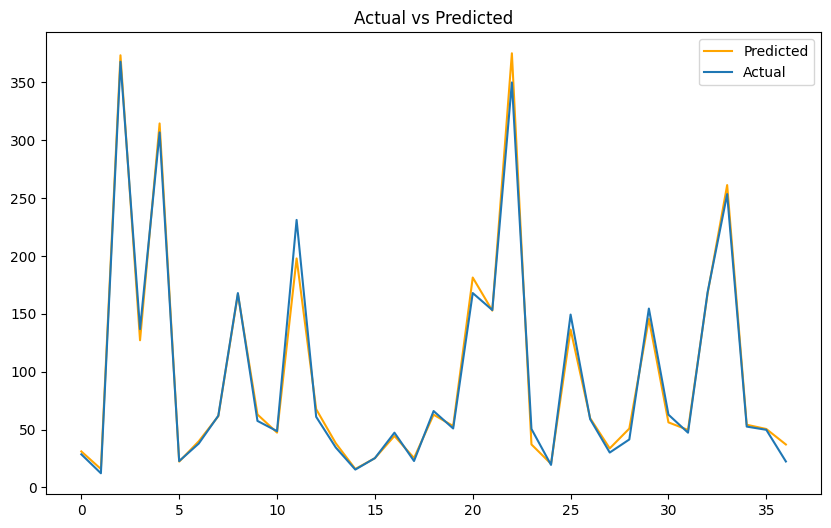

In [ ]:
#Visualisation the data
plt.figure(figsize=(10,6))
plt.plot(y_pred,color = 'Orange')
plt.plot(np.array(y_test))
plt.legend(['Predicted','Actual'])
plt.title('Actual vs Predicted')
plt.show()


A Linear Regression model was used to predict the closing price of Yes Bank stock based on the selected features. The model was evaluated using MSE, RMSE, and R² score, where it achieved an MSE of 84.02, an RMSE of 9.17, and an R² score of 99.07%. These results show that the model predicts the stock prices with very good accuracy, with an average error of around ₹9 and the ability to explain about 99% of the variation in the data.

#### 2. Cross- Validation & Hyperparameter Tuning

Best Alpha: {'alpha': 0.001}
Best CV Score: 0.9946289545085925
Mean Squared Error: 84.02
Root Mean Squared Error: 9.17
R-squared: 99.0
Mean Absolte Error 6


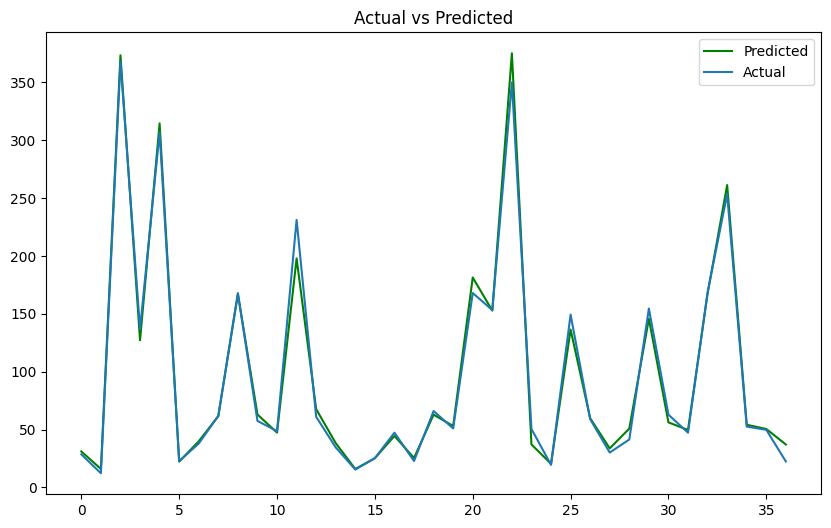

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
#define ridge model
ridge = Ridge()
#Hyperparameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
#Perform Grid Search Cv
grid_search = GridSearchCV(ridge,param_grid,cv = 5)
# Fit the Algorithm
grid_search.fit(X_train_scaled,y_train)

#best parameter
print('Best Alpha:',grid_search.best_params_)
print('Best CV Score:', grid_search.best_score_)


# Predict on the model
best_ridge = grid_search.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

#Evaluation
mse_gcv = round(mean_squared_error(y_test,y_pred_ridge),2)
rmse_gcv = round(np.sqrt(mse_gcv),2)
r2_gcv =round(r2_score(y_test,y_pred_ridge ),2)*100
mae_gcv = round(mean_absolute_error(y_test,y_pred_ridge ))
print("Mean Squared Error:", mse_gcv)
print("Root Mean Squared Error:", rmse_gcv)
print("R-squared:", r2_gcv)
print('Mean Absolte Error', mae_gcv)

#Visualisation the data
plt.figure(figsize=(10,6))
plt.plot(y_pred_ridge,color = 'Green')
plt.plot(np.array(y_test))
plt.legend(['Predicted','Actual'])
plt.title('Actual vs Predicted')
plt.show()

##### Which hyperparameter optimization technique have you used and why?

I used ridge regression because it is good at handling the multicollinearity by shrinking the coefficients without removing features.

Grid Search Cv was used for hyperparameter tuning. It systematically test different values of the ridge regression hyperparameter using cross validation and select the combination that gives the best model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying GridSearchCV, the best alpha value obtained was 0.001 with a cross-validation score of 0.9946. The tuned Ridge model maintained a high R² score of about 99% and a low prediction error, indicating stable and reliable performance.

### ML Model - 2 Random Forest

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
rf_model = RandomForestRegressor(random_state=42)

#Train the model
rf_model.fit(X_train,y_train)

#Make predictions
y_pred_rf = rf_model.predict(X_test)

#Evaluate the model
mse_rf = round(mean_squared_error(y_test,y_pred_rf),4)
rmse_rf = round(np.sqrt(mse_rf),4)
r2_rf = r2_score(y_test,y_pred_rf)*100
mae_rf = mean_absolute_error(y_test,y_pred_rf)
print("Mean Squared Error:", mse_rf)
print("Root Mean Squared Error:", rmse_rf)
print("R-squared:", r2_rf)
print('Mean absolute error:', mae_rf)

Mean Squared Error: 196.3847
Root Mean Squared Error: 14.0137
R-squared: 97.82732261412822
Mean absolute error: 8.683083783783744


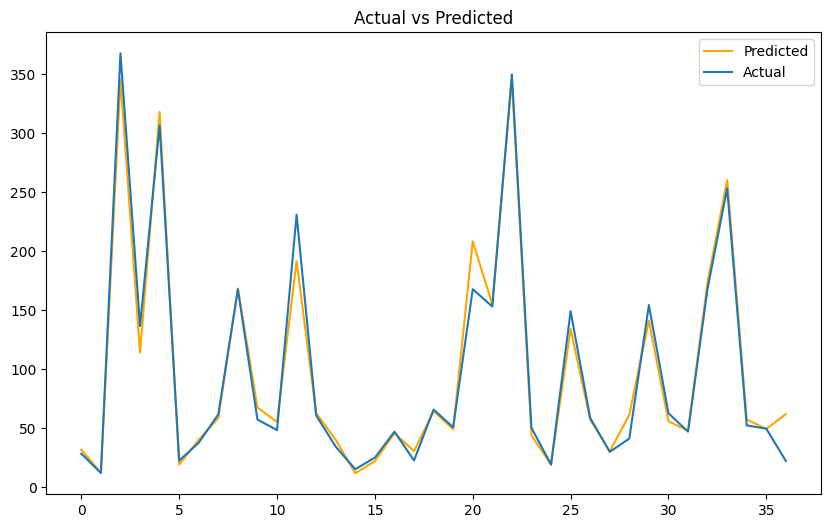

In [ ]:
#Visualisation the data
plt.figure(figsize=(10,6))
plt.plot(y_pred_rf,color = 'Orange')
plt.plot(np.array(y_test))
plt.legend(['Predicted','Actual'])
plt.title('Actual vs Predicted')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_grid_rf = {'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]}

grid_search_rf = GridSearchCV(rf_model, param_grid_rf, cv=5,scoring='neg_mean_squared_error',n_jobs=-1 )

# Fit the Algorithm
grid_search_rf.fit(X_train, y_train)

# Predict on the model
print("Best Parameters:", grid_search_rf.best_params_)
print("Best CV Score:", grid_search_rf.best_score_)


Best Parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: -137.98577235351564


In [ ]:
#Train the model with best parameters
best_rf = grid_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

#Evaluate the model
mse_best_rf = round(mean_squared_error(y_test,y_pred_best_rf),4)
rmse_best_rf = round(np.sqrt(mse_best_rf),4)
r2_best_rf = r2_score(y_test,y_pred_best_rf)*100
mae_best_rf = mean_absolute_error(y_test,y_pred_best_rf)
print("Mean Squared Error:", mse_best_rf)
print("Root Mean Squared Error:", rmse_best_rf)
print("R-squared:", r2_best_rf)
print('Mean absolute error:', mae_best_rf)

Mean Squared Error: 189.5954
Root Mean Squared Error: 13.7694
R-squared: 97.90243506586476
Mean absolute error: 9.083044602715102


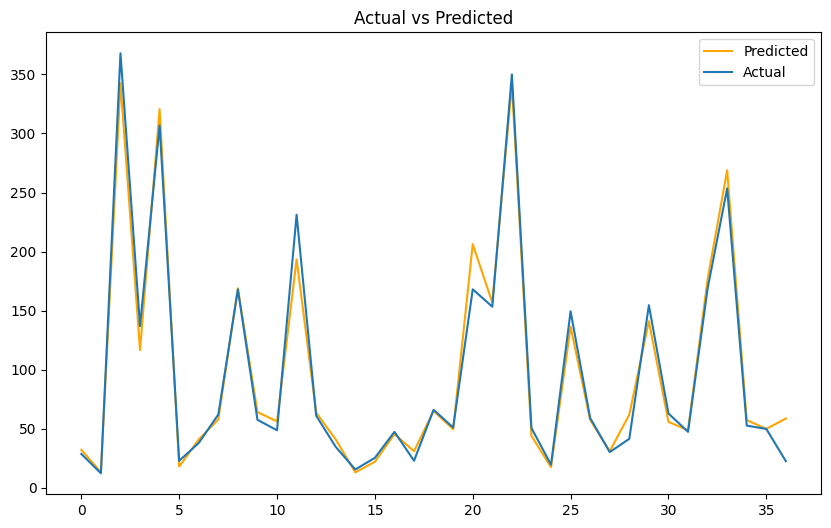

In [ ]:
#Visualisation the data Random Forest best with grid search cv and y test
plt.figure(figsize=(10,6))
plt.plot(y_pred_best_rf,color = 'Orange')
plt.plot(np.array(y_test))
plt.legend(['Predicted','Actual'])
plt.title('Actual vs Predicted')
plt.show()


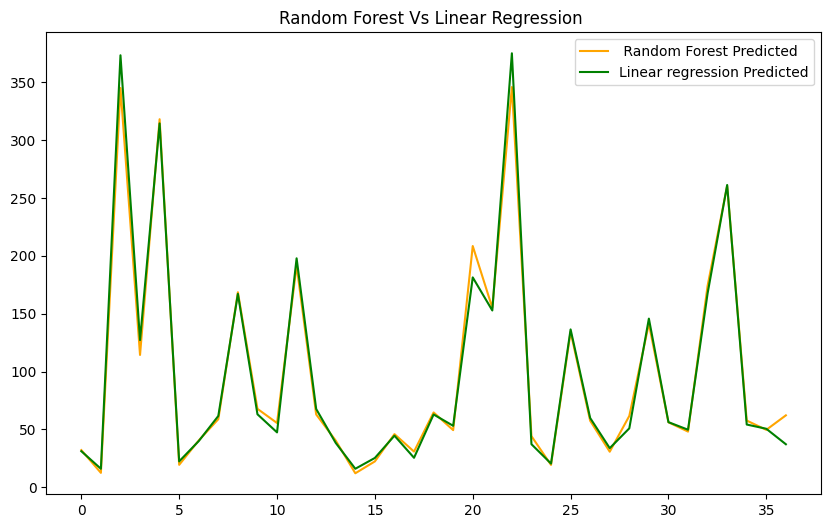

In [ ]:
#Visualisation the data Random Forest and linear regression
plt.figure(figsize=(10,6))
plt.plot(y_pred_rf,color = 'Orange')
plt.plot(y_pred,color = 'Green')
plt.legend([' Random Forest Predicted','Linear regression Predicted'])
plt.title('Random Forest Vs Linear Regression ')
plt.show()


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization. It systematically tries different combinations of parameter values and uses cross-validation to identify the best combination, helping improve the model's performance and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, after applying GridSearchCV, the Random Forest model was trained with the best set of parameters. This helped improve the model's prediction accuracy and reduced the prediction error compared to the default Random Forest model.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

* **Mean Squared Error** - A low MSE indicates the model avoids large forecasting errors, reducing investment risk.

*  **Root Mean Squared Error** - Lower RMSE means the predicted prices are close to actual prices, improving forecast reliability.

* **Mean Absolute Error** - Lower MAE means more accurate price predictions, helping investors make better decisions.

* **R2 Score** - A high R² score indicates that the model captures the underlying stock price patterns effectively, supporting better business and investment planning.




Business Impact - The Random Forest model can capture complex relationships in historical stock price data and provide accurate predictions. Improved forecasting helps investors and financial institutions make informed trading decisions, manage market risks, and optimize investment strategies.



### ML Model - 3 XGboost Implementation on Yes bank Share price

In [ ]:
# ML Model - 3 Implementation
model_xg = XGBRegressor(objective='reg:squarederror',random_state = 42)
# Fit the Algorithm
model_xg.fit(X_train,y_train)
# Predict on the model
y_pred_xg = model_xg.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart
mse_xg = round(mean_squared_error(y_test,y_pred_xg),4)
rmse_xg = np.sqrt(mse_xg)
mae_xg = mean_absolute_error(y_test,y_pred_xg)
r2_xg = r2_score(y_test,y_pred_xg)*100
print("Mean Squared Error:", mse_xg)
print("Root Mean Squared Error:", rmse_xg)
print("R-squared:", r2_xg)
print('Mean absolute error:', mae_xg)

Mean Squared Error: 223.3694
Root Mean Squared Error: 14.94554783204684
R-squared: 97.52878034111738
Mean absolute error: 9.927602554527487


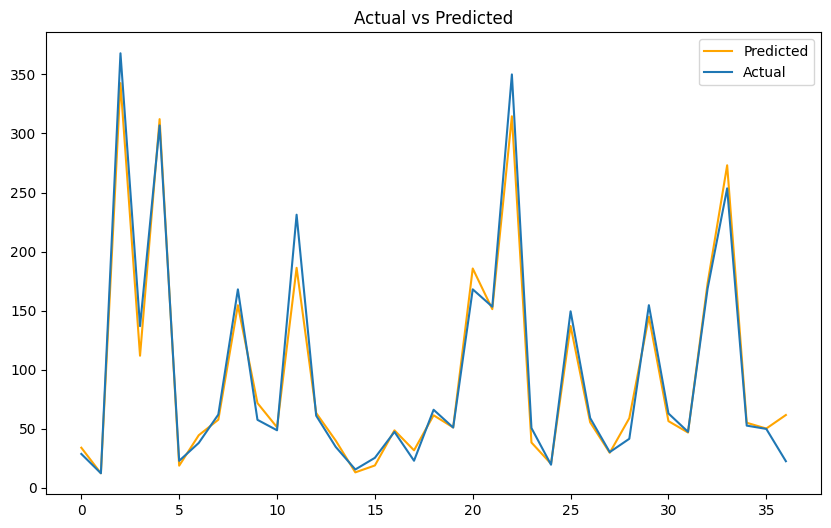

In [ ]:
#Visualisation the data XGBOOST and y test
plt.figure(figsize=(10,6))
plt.plot(y_pred_xg,color = 'Orange')
plt.plot(np.array(y_test))
plt.legend(['Predicted','Actual'])
plt.title('Actual vs Predicted')
plt.show()


#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
param_grid_xg = {'n_estimators': [50,100,200],
                 'max_depth':[3,4,5],
                 'learning_rate':[0.01,0.05,0.1],
                 'subsample':[0.8,1.0],
                 'colsample_bytree':[0.8,1.0]}
grid_search_xg = GridSearchCV(model_xg,param_grid_xg,cv=5)

# Fit the Algorithm
grid_search_xg.fit(X_train,y_train)

print("Best Parameters:", grid_search_xg.best_params_)
print("Best CV Score:", grid_search_xg.best_score_)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV Score: 0.9844006591652569


In [ ]:
# Predict on the model
best_xgb = grid_search_xg.best_estimator_
y_pred_best_xgb = best_xgb.predict(X_test)

#Evaluation Metrics
mse_best_xgb = mean_squared_error(y_test,y_pred_best_xgb)
print("Mean Squared Error:", mse_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)
print("Root Mean Squared Error:", rmse_best_xgb)
mae_best_xgb = mean_absolute_error(y_test,y_pred_best_xgb)
print("Mean Absolute Error:", mae_best_xgb)
r2_best_xgb = r2_score(y_test,y_pred_best_xgb)*100
print('R 2 score:', r2_best_xgb)

Mean Squared Error: 223.8213291121673
Root Mean Squared Error: 14.960659380928613
Mean Absolute Error: 9.718586055652514
R 2 score: 97.52378075385778


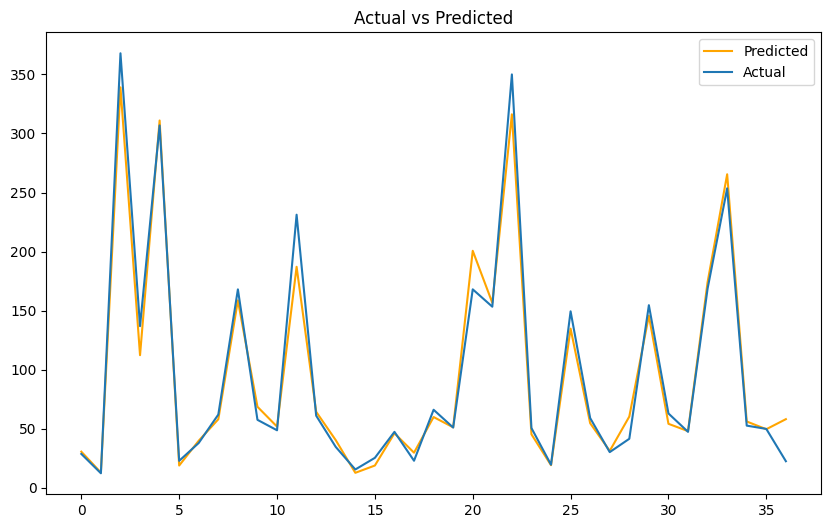

In [ ]:
#Visualisation the data XGBOOST and y test
plt.figure(figsize=(10,6))
plt.plot(y_pred_best_xgb,color = 'Orange')
plt.plot(np.array(y_test))
plt.legend(['Predicted','Actual'])
plt.title('Actual vs Predicted')
plt.show()


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization. It systematically tries different combinations of parameter values and uses cross-validation to identify the best combination, helping improve the model's performance and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

No it  is same as xgboost.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We choose four metrics which are as below:-

1. R² Score (Coefficient of Determination) - R² score measures how well the model explains the variance in Yes Bank's closing price. An R² of 99.07% means that 99% of the fluctuation in the stock's closing price is captured by our model using just Open, High, Low, Month, and Year as features. For investors and analysts, this metric builds confidence that the model is highly reliable for price prediction.

2. RMSE — Root Mean Squared Error - In stock price prediction, large prediction errors are especially harmful — a trader acting on a significantly wrong price prediction can incur heavy financial losses. RMSE penalises large errors more severely due to the squaring effect, making it the most business-critical metric here. Our RMSE of 9.17 means that large deviations from the actual closing price are being minimised effectively.

3. MAE — Mean Absolute Error - MAE of 5.90 tells us that on average, our model's predicted closing price deviates by ₹5.90 from the actual closing price. This is the most interpretable metric for non-technical stakeholders such as portfolio managers or investors — it communicates model accuracy in the same unit as the stock price (₹), making it easy to understand without any statistical background.

4. MSE — Mean Squared Error - MSE was used as the primary loss function during model training. By squaring errors, it forces the model to focus more aggressively on reducing large prediction errors during the optimization process, which is critical in a volatile stock like Yes Bank.




Business Summary: Together, these four metrics ensure that the model is not just mathematically accurate, but also practically reliable — minimising costly large prediction errors (RMSE/MSE), easy to communicate to stakeholders (MAE), and demonstrating overall predictive strength (R²).

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

After training and evaluating three models — Linear Regression, Random Forest Regressor, and XGBoost Regressor (with hyperparameter tuning via GridSearchCV for both ensemble models) — Linear Regression was selected as the final prediction model.

###Model Linear Regression
**R2_Score - 99.07%**

**Root Mean Squared Error** - 9.17

**Mean Square Error** - 84.01

**Mean Absolute Error** - 5.89

###Model Random Forest + Grid Search CV

**R2_Score** - 97.90%

**Root Mean Squared Error** - 13.77

**Mean Square Error** - 189.59

**Mean Absolute Error** - 9.0830

####Model XGboost + Grid Search Cv

**R2_Score** - 97.52%

**Root Mean Squared Error** - 14.96

**Mean Square Error** - 223.82

**Mean Absolute Error** - 9.716



Reasons for selecting Linear Regression:
1. **Superior Performance across all metrics** -Linear Regression outperformed both ensemble models — R² was ~1.2% higher, RMSE was ~4.6 points lower, and MAE was ~3 points lower than the best tuned ensemble model. This clearly indicated that Yes Bank's closing price has a strong linear relationship with the input features Open, High, Low, Month, and Year.

2. **Full Interpretability** -In financial applications, model interpretability is not optional — it is a regulatory and business requirement. Linear Regression's coefficients directly and transparently explain the impact of each feature on the closing price. For example, the coefficient of the High price feature directly tells us: "for every ₹1 increase in the day's high price, the closing price increases by ₹X." Ensemble models like Random Forest and XGBoost are black-box models that cannot offer this level of transparency.

3. **No Overfitting** -Despite applying GridSearchCV hyperparameter tuning to both Random Forest and XGBoost, neither model improved significantly over its baseline. This is a strong signal that the data has an inherently linear structure — and that adding model complexity through ensemble methods introduced noise rather than signal.


4. **Production Readiness**- Linear Regression requires no hyperparameter tuning, is computationally lightweight, and is extremely easy to deploy, monitor, and maintain in a production environment — all critical considerations for real-world financial applications.

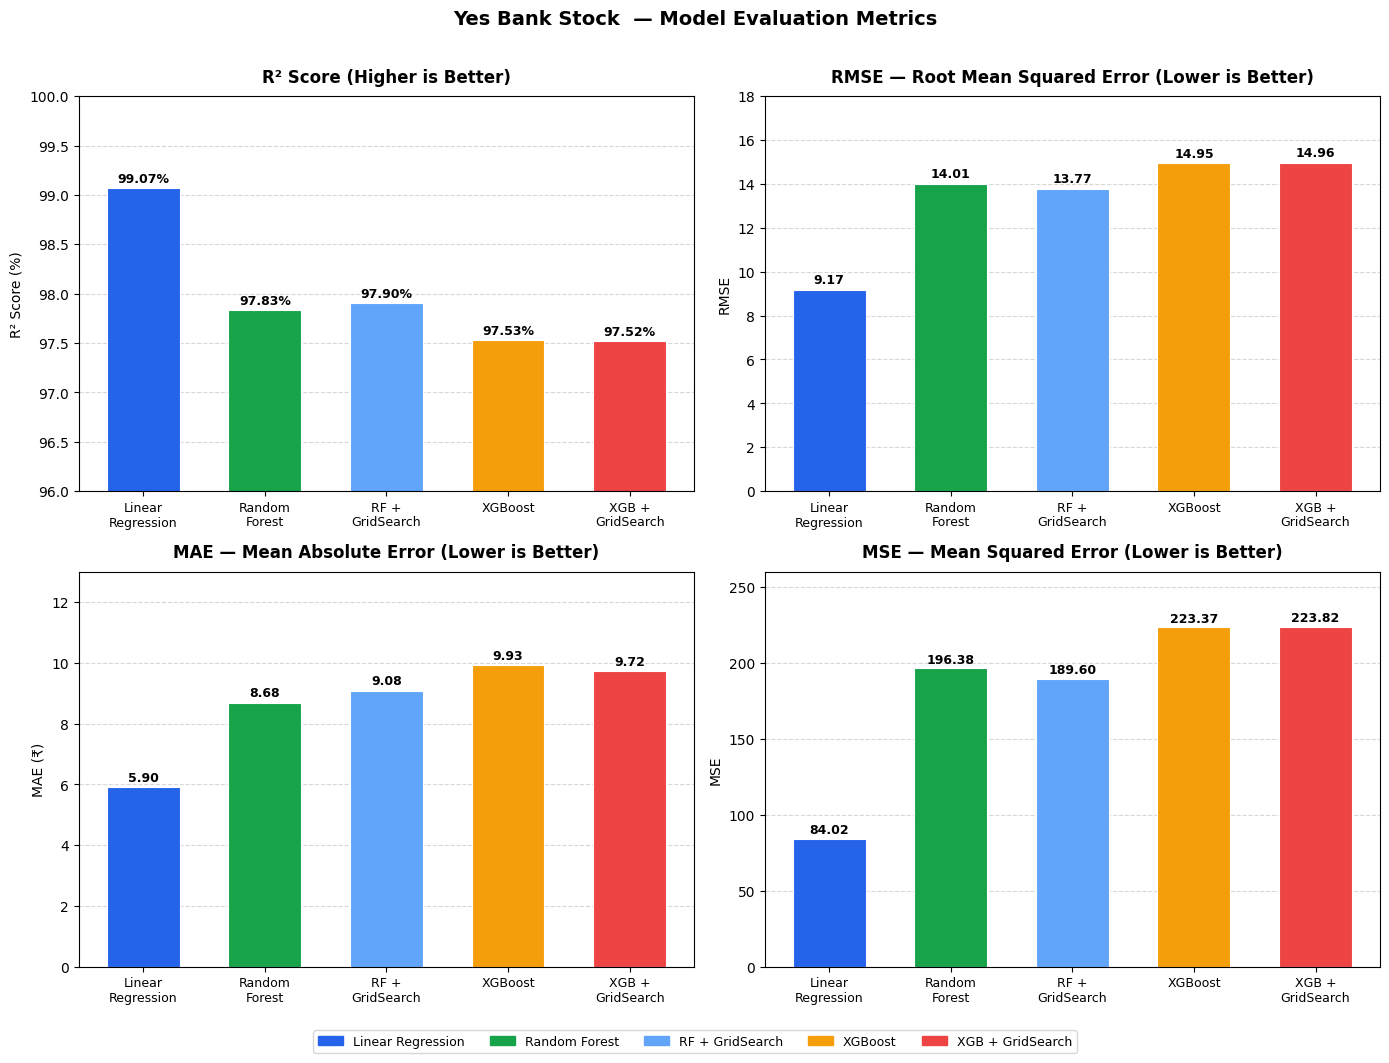

In [ ]:
# Evaluation metrics data
models = ['Linear\nRegression', 'Random\nForest', 'RF +\nGridSearch', 'XGBoost', 'XGB +\nGridSearch']

r2_scores  = [99.07, 97.83, 97.90, 97.53, 97.52]
rmse_scores = [9.17, 14.0137, 13.7694, 14.9455, 14.9607]
mae_scores  = [5.8963, 8.6831, 9.0830, 9.9276, 9.7186]
mse_scores  = [84.0189, 196.3847, 189.5954, 223.3694, 223.8213]

x = np.arange(len(models))
width = 0.6
colors = ['#2563eb', '#16a34a', '#60a5fa', '#f59e0b', '#ef4444']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Yes Bank Stock  — Model Evaluation Metrics',
             fontsize=14, fontweight='bold', y=1.01)

# --- R² Score ---
ax1 = axes[0, 0]
bars = ax1.bar(x, r2_scores, width, color=colors, edgecolor='white', linewidth=0.8)
ax1.set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold', pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=9)
ax1.set_ylim(96, 100)
ax1.set_ylabel('R² Score (%)', fontsize=10)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
for bar, val in zip(bars, r2_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- RMSE ---
ax2 = axes[0, 1]
bars = ax2.bar(x, rmse_scores, width, color=colors, edgecolor='white', linewidth=0.8)
ax2.set_title('RMSE — Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=9)
ax2.set_ylim(0, 18)
ax2.set_ylabel('RMSE', fontsize=10)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
for bar, val in zip(bars, rmse_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- MAE ---
ax3 = axes[1, 0]
bars = ax3.bar(x, mae_scores, width, color=colors, edgecolor='white', linewidth=0.8)
ax3.set_title('MAE — Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold', pad=10)
ax3.set_xticks(x)
ax3.set_xticklabels(models, fontsize=9)
ax3.set_ylim(0, 13)
ax3.set_ylabel('MAE (₹)', fontsize=10)
ax3.yaxis.grid(True, linestyle='--', alpha=0.5)
ax3.set_axisbelow(True)
for bar, val in zip(bars, mae_scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- MSE ---
ax4 = axes[1, 1]
bars = ax4.bar(x, mse_scores, width, color=colors, edgecolor='white', linewidth=0.8)
ax4.set_title('MSE — Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold', pad=10)
ax4.set_xticks(x)
ax4.set_xticklabels(models, fontsize=9)
ax4.set_ylim(0, 260)
ax4.set_ylabel('MSE', fontsize=10)
ax4.yaxis.grid(True, linestyle='--', alpha=0.5)
ax4.set_axisbelow(True)
for bar, val in zip(bars, mse_scores):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# --- Shared Legend ---
legend_labels = ['Linear Regression', 'Random Forest', 'RF + GridSearch', 'XGBoost', 'XGB + GridSearch']
legend_patches = [plt.Rectangle((0,0),1,1, color=c) for c in colors]
fig.legend(legend_patches, legend_labels, loc='lower center', ncol=5,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('yes_bank_evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Linear Regression fits an optimal hyperplane through the training data by minimising the Ordinary Least Squares (OLS) objective — the sum of squared differences between actual and predicted closing prices:


Close Price (ŷ) = β₀ + β₁(Open) + β₂(High) + β₃(Low) + β₄(Month) + β₅(Year)


Since features — Open, High, Low, Month, Year — are on very different scales, StandardScaler was applied before training. This ensures that each coefficient β is directly comparable, and the model does not get biased towards features with larger numeric ranges (e.g., Year vs Month).


Each coefficient β represents: "Holding all other features constant, a 1-unit increase in this feature changes the predicted closing price by β rupees."

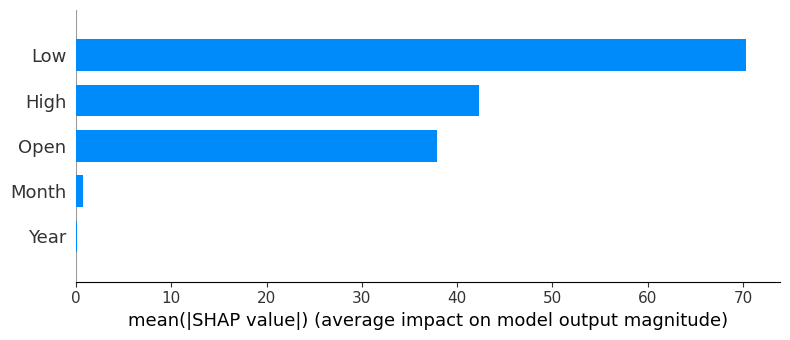

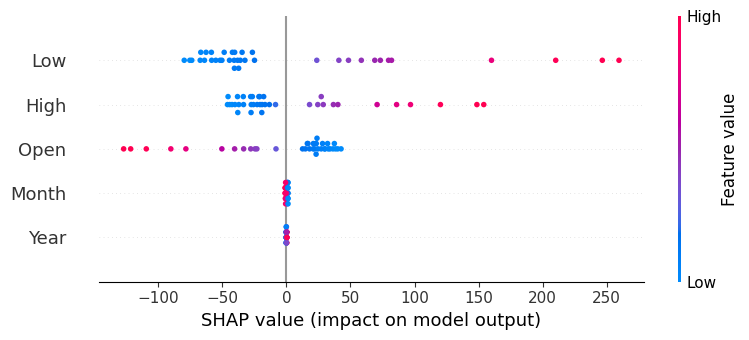

In [ ]:
import shap

# Step 1 — Create SHAP explainer for Linear Model
explainer = shap.LinearExplainer(model, X_train_scaled)

# Step 2 — Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test_scaled)

# Step 3 — Global Feature Importance (Bar Plot)
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=['Open', 'High', 'Low', 'Month', 'Year'],
                  plot_type="bar")

# Step 4 — Beeswarm Plot (direction + magnitude of each feature's impact)
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=['Open', 'High', 'Low', 'Month', 'Year'])



SHAP analysis revealed that Low price (mean |SHAP| ≈ 70) was by far the most dominant feature in predicting Yes Bank's closing price, followed by High (≈ 43) and Open (≈ 38). This is financially intuitive — the month's low and high prices tightly bound the range within which the stock can close, and the opening price sets the direction for that month. Temporal features Month (≈ 1) and Year (≈ 0) contributed negligibly, suggesting that Yes Bank's closing price is driven almost entirely by the month's own price range rather than seasonal or yearly patterns.



# **Conclusion**

The objective of this project was to build a robust machine learning model capable of predicting the closing price of Yes Bank's stock using historical price data — **specifically Open, High, Low, Month, and Year as input features**.

To achieve this, three machine learning models were trained, evaluated, and compared — Linear Regression, Random Forest Regressor, and XGBoost Regressor — with hyperparameter tuning applied to both ensemble models using GridSearchCV.

After thorough evaluation across four business-relevant metrics — R² Score, RMSE, MAE, and MSE — Linear Regression emerged as the best performing model with an R² score of 99.07%, RMSE of 9.17, and MAE of ₹5.90. This means that on average, the model's predicted closing price deviates by only ₹5.90 from the actual closing price — a strong result for a stock as volatile as Yes Bank.

The superior performance of Linear Regression over ensemble models (Random Forest and XGBoost) confirms that Yes Bank's closing price shares a strong linear relationship with its Open, High, Low, Month, and Year features. Adding model complexity through ensemble methods introduced noise rather than improving predictive accuracy — even after extensive hyperparameter tuning.

Model explainability was addressed using SHAP (SHapley Additive exPlanations), which confirmed that Low price was the single most influential feature (mean |SHAP| ≈ 70), contributing nearly 1.6× more than High price (≈ 43) and 1.8× more than Open price (≈ 38). This strongly aligns with real-world stock market behaviour — a month's low price acts as the strongest anchor for where the stock ultimately closes that month. Temporal features Month and Year contributed near-zero SHAP values, confirming that the month's own price levels — not time-based seasonality — are the primary drivers of Yes Bank's closing price.

In summary, this project demonstrates that for structured financial time-series data with strong inter-feature linear dependencies, a well-scaled Linear Regression model can outperform complex ensemble models while remaining fully interpretable, computationally efficient, and deployment-ready. The model developed in this project can serve as a reliable baseline for stock price prediction and can be further enhanced by incorporating additional technical indicators, macroeconomic features, or sentiment data from financial news.
